In [1]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt

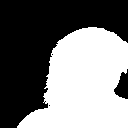

In [79]:
train_data_path = './Images/Train'
test_data_path = './Images/Test/'

train_images_path = os.path.join(train_data_path, 'Images')
train_masks_path = os.path.join(train_data_path, 'Masks')

test_images_path = os.path.join(test_data_path, 'Images')
test_masks_path = os.path.join(test_data_path, 'Masks')

image_names = os.listdir(train_images_path)
test_image_names = os.listdir(test_images_path)

train_images = [os.path.join(train_images_path, image_name) for image_name in image_names]
train_masks = [os.path.join(train_masks_path, image_name) for image_name in image_names]

test_images = [os.path.join(test_images_path, image_name) for image_name in test_image_names]
test_masks = [os.path.join(test_masks_path, image_name) for image_name in test_image_names]

example_mask = tf.keras.utils.load_img(train_masks[0])
example_mask

In [95]:
X_train = []
y_train = []

for i in range(0, 4000):
    img = tf.keras.utils.load_img(train_images[i])
    img = tf.keras.utils.img_to_array(img)
    X_train.append(img)

    mask = tf.keras.utils.load_img(train_masks[i], color_mode='grayscale')
    mask = tf.keras.utils.img_to_array(mask)
    y_train.append(mask)

    if i%100 == 0 or i==len(train_images):
        print(f"\r{i}/{len(train_images)} images loaded...", end='')

3900/18698 images loaded...

In [80]:
X_test = []
y_test = []

for i in range(0, 2000):
    img = tf.keras.utils.load_img(test_images[i])
    img = tf.keras.utils.img_to_array(img)
    X_test.append(img)

    mask = tf.keras.utils.load_img(test_masks[i], color_mode='grayscale')
    mask = tf.keras.utils.img_to_array(mask)
    y_test.append(mask)

    if i%100 == 0 or i==len(test_images):
        print(f"\r{i}/{len(test_images)} images loaded...", end='')

1900/3740 images loaded...

In [82]:
y_test_scaled = np.array(y_test)/255.

In [96]:
X_train = np.array(X_train)
y_train = np.array(y_train)

X_train.shape, y_train.shape

((4000, 128, 128, 3), (4000, 128, 128, 1))

In [97]:
np.unique(y_train[0])

array([  0., 255.], dtype=float32)

In [6]:
def encoder_block(input_, filters):
    out1 = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), padding='same', activation='relu')(input_)
    out2 = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), padding='same', activation='relu')(out1)
    output = tf.keras.layers.MaxPool2D(strides=(2, 2))(out2)
    return out2, output

def decoder_block(input_, skip, filters):
    out1 = tf.keras.layers.Conv2DTranspose(filters=filters, kernel_size=(2, 2), strides=(2, 2), padding='same', activation='relu')(input_)
    out2 = tf.keras.layers.concatenate([skip, out1], axis=-1)
    out3 = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), activation='relu', padding='same')(out2)
    output = tf.keras.layers.Conv2D(filters=filters, kernel_size=(3, 3), activation='relu', padding='same')(out3)
    return output
    
input_ = tf.keras.Input(shape=(X_train.shape[1:]))
rescaled_input = tf.keras.layers.Rescaling(scale=1/255.)(input_)

skip1, enc1 = encoder_block(rescaled_input, 8)
skip2, enc2 = encoder_block(enc1, 16)
skip3, enc3 = encoder_block(enc2, 32)
skip4, enc4 = encoder_block(enc3, 64)

enc_pen_ultimate = tf.keras.layers.Conv2D(filters=1024, kernel_size=(3, 3), padding='same', activation='relu')(enc4)
enc_ultimate = tf.keras.layers.Conv2D(filters=1024, kernel_size=(3, 3), padding='same', activation='relu')(enc_pen_ultimate)

dec1 = decoder_block(enc_ultimate, skip4, 64)
dec2 = decoder_block(dec1, skip3, 32)
dec3 = decoder_block(dec2, skip2, 16)
dec4 = decoder_block(dec3, skip1, 8)

final_output = tf.keras.layers.Conv2D(filters=1, kernel_size=(1, 1), activation='sigmoid')(dec4)

model = tf.keras.Model(inputs=[input_], outputs=[final_output])

In [7]:
model.compile(loss=tf.keras.losses.binary_crossentropy, optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃                ┃              ┃  Param ┃               ┃
┃ Layer (type)   ┃ Output Shape ┃      # ┃ Connected to  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer    │ (None, 128,  │      0 │ -             │
│ (InputLayer)   │ 128, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling      │ (None, 128,  │      0 │ input_layer[… │
│ (Rescaling)    │ 128, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d         │ (None, 128,  │    224 │ rescaling[0]… │
│ (Conv2D)       │ 128, 8)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_1       │ (None, 128,  │    584 │ conv2d[0][0]  │
│ (Conv2D)       │ 128, 8)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ max_pooling2d  │ (None, 64,   │      0 │ conv2d_1[0][… │
│ (MaxPooling2D) │ 64, 8)       │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_2       │ (None, 64,   │  1,168 │ max_pooling2… │
│ (Conv2D)       │ 64, 16)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_3       │ (None, 64,   │  2,320 │ conv2d_2[0][… │
│ (Conv2D)       │ 64, 16)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ max_pooling2d… │ (None, 32,   │      0 │ conv2d_3[0][… │
│ (MaxPooling2D) │ 32, 16)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_4       │ (None, 32,   │  4,640 │ max_pooling2… │
│ (Conv2D)       │ 32, 32)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_5       │ (None, 32,   │  9,248 │ conv2d_4[0][… │
│ (Conv2D)       │ 32, 32)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ max_pooling2d… │ (None, 16,   │      0 │ conv2d_5[0][… │
│ (MaxPooling2D) │ 16, 32)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_6       │ (None, 16,   │ 18,496 │ max_pooling2… │
│ (Conv2D)       │ 16, 64)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_7       │ (None, 16,   │ 36,928 │ conv2d_6[0][… │
│ (Conv2D)       │ 16, 64)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ max_pooling2d… │ (None, 8, 8, │      0 │ conv2d_7[0][… │
│ (MaxPooling2D) │ 64)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_8       │ (None, 8, 8, │ 590,8… │ max_pooling2… │
│ (Conv2D)       │ 1024)        │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_9       │ (None, 8, 8, │ 9,438… │ conv2d_8[0][… │
│ (Conv2D)       │ 1024)        │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_transp… │ (None, 16,   │ 262,2… │ conv2d_9[0][… │
│ (Conv2DTransp… │ 16, 64)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ concatenate    │ (None, 16,   │      0 │ conv2d_7[0][… │
│ (Concatenate)  │ 16, 128)     │        │ conv2d_trans… │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_10      │ (None, 16,   │ 73,792 │ concatenate[… │
│ (Conv2D)       │ 16, 64)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_11      │ (None, 16,   │ 36,928 │ conv2d_10[0]… │
│ (Conv2D)       │ 16, 64)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ conv2d_transp… │ (None, 32,   │  8,224 │ conv2d_11[0]… │
│ (Conv2DTransp… │ 32, 32)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ concatenate_1  │ (None, 32,   │      0 │ conv

 Total params: 10,522,809 (40.14 MB)

 Trainable params: 10,522,809 (40.14 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
y_train_scaled = y_train/255.

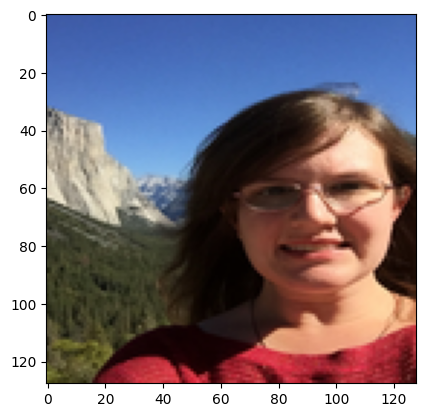

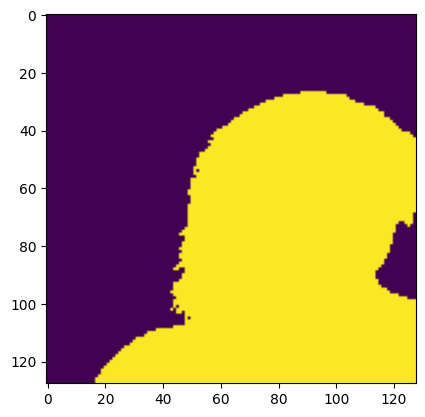

In [99]:
plt.imshow(X_train[0].astype(int))
plt.show()
plt.imshow(y_train_scaled[0])
plt.show()

In [100]:
history = model.fit(X_train, y_train_scaled, epochs=9, validation_split=0.1)

Epoch 1/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 67s 593ms/step - accuracy: 0.9529 - loss: 0.1238 - val_accuracy: 0.9497 - val_loss: 0.1363
Epoch 2/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 72s 636ms/step - accuracy: 0.9604 - loss: 0.1036 - val_accuracy: 0.9565 - val_loss: 0.1172
Epoch 3/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 78s 691ms/step - accuracy: 0.9655 - loss: 0.0904 - val_accuracy: 0.9587 - val_loss: 0.1141
Epoch 4/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 84s 747ms/step - accuracy: 0.9689 - loss: 0.0813 - val_accuracy: 0.9591 - val_loss: 0.1112
Epoch 5/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 92s 814ms/step - accuracy: 0.9717 - loss: 0.0739 - val_accuracy: 0.9582 - val_loss: 0.1231
Epoch 6/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 100s 884ms/step - accuracy: 0.9749 - loss: 0.0651 - val_accuracy: 0.9603 - val_loss: 0.1167
Epoch 7/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 104s 922ms/step - accuracy: 0.9767 - loss: 0.0600 - val_accuracy: 0.9596 - val_loss: 0.1306
Epoch 8/9
113/113 ━━━━━━━━━━━━━━━━━━━━ 106s 940ms/step - accuracy: 0.9786 - loss: 0.0551

In [101]:
img_path = './Images/test_image/test.jpeg'
test_image = tf.keras.utils.img_to_array(tf.keras.utils.load_img(img_path, target_size=(128, 128)))

pred = model.predict(np.expand_dims(test_image, axis=0))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [102]:
mask = (pred > 0.5).astype(int)

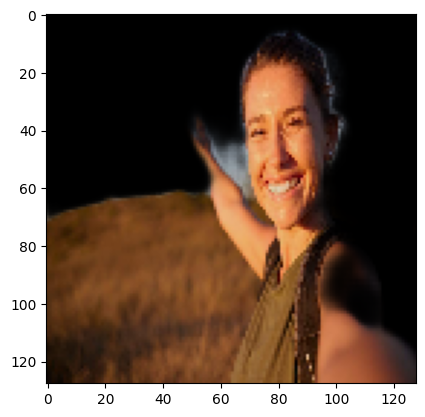

In [103]:
plt.imshow(test_image/255 * pred)

In [104]:
evaluation = model.evaluate(np.array(X_test), y_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.9308 - loss: 0.2659


In [ ]:
# With 2000 training examples - Training accuracy = 97%, Validation accuracy = 97%, Test accuracy = 92%
# With 4000 training examples - Training accuracy = 97%, Validation accuracy = 96%, Test accuracy = 93%

In [105]:
model.save('model_v1.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step


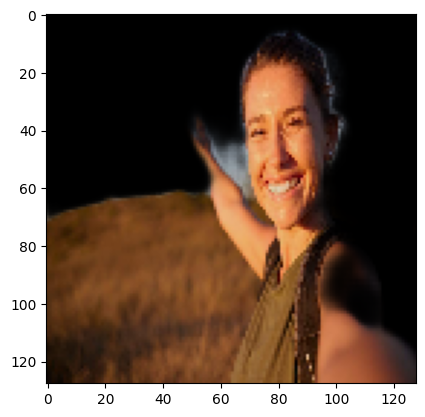

In [109]:
loaded_model = tf.keras.models.load_model('model_v1.keras')
plt.imshow(test_image/255 * loaded_model.predict(np.expand_dims(test_image, axis=0))[0])